# Solving nonlinear equations

We want to solve
$$
f(x) = 0
$$
where $f$ is nonlinear, e.g. $x - \cos x - 1 = 0$ or $e^x - 5x + 2 = 0$. Such equations rarely have a closed-form solution, so we use **iterative methods**: starting from one or two initial guesses we generate a sequence $x_0, x_1, x_2, \dots$ that (hopefully) converges to a root $x^*$.

For every method we ask the same two questions:

1. **Does it converge, and from which starting values?** (robustness)
2. **How fast does it converge?** (efficiency)

**Learning goals.** After this notebook you should be able to

- explain, implement and use the bisection method, fixed-point iteration, Newton's method and the secant method,
- define the *order of convergence* and estimate it from computed iterates,
- predict when a fixed-point iteration or Newton's method converges, and recognise typical failures,
- choose sensible stopping criteria,
- extend Newton's method to systems of equations and to optimisation,
- combine methods for robustness, and use `scipy.optimize`.

Some examples follow the textbook (Turner et al.).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import optimize

np.set_printoptions(precision=6)
pd.set_option("display.float_format", "{:.3e}".format)

## 1 How fast does an iteration converge?

Let $x_n \to x^*$ and define the **error** $e_n = |x_n - x^*|$.

**Definition (order of convergence).** The sequence converges with **order** $p \ge 1$ and **asymptotic constant** $C$ if
$$
\lim_{n\to\infty} \frac{e_{n+1}}{e_n^{\,p}} = C, \qquad 0 < C < \infty,
$$
where for $p = 1$ we also require $C < 1$.

- $p = 1$: **linear** convergence. Each step multiplies the error by roughly $C$, i.e. we gain a *fixed* number of correct digits ($-\log_{10} C$) per step.
- $1 < p < 2$: **superlinear** convergence.
- $p = 2$: **quadratic** convergence. The number of correct digits roughly *doubles* per step.

Example with $e_0 = 0.1$:

| $n$ | linear, $C = 1/2$ | quadratic, $C = 1$ |
|---|---|---|
| 1 | $5\cdot10^{-2}$ | $10^{-2}$ |
| 2 | $2.5\cdot10^{-2}$ | $10^{-4}$ |
| 3 | $1.25\cdot10^{-2}$ | $10^{-8}$ |
| 4 | $6.25\cdot10^{-3}$ | $10^{-16}$ |

**Seeing the order in a plot.** In a plot of $\log e_n$ versus $n$ (`plt.semilogy`), linear convergence is a *straight line* with slope $\log C$, while superlinear convergence gives a curve that bends *downwards*.

**Estimating the order from data.** If $e_{n+1} \approx C e_n^p$ for consecutive $n$, dividing two such relations and taking logarithms gives
$$
p \approx \frac{\log(e_{n+1}/e_n)}{\log(e_n/e_{n-1})}.
$$
To compute $e_n$ we need $x^*$; in practice we use a very accurate reference solution.

estimated order, linear   : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
estimated order, quadratic: [2. 2.]


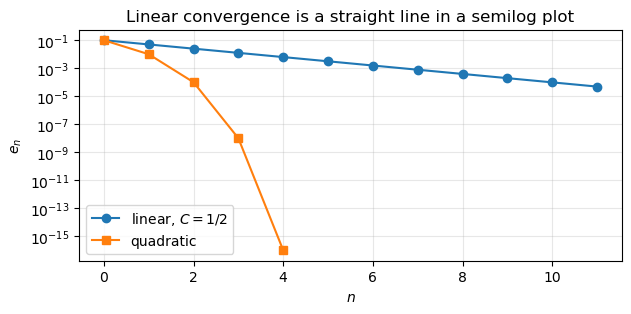

In [2]:
def errors(xs, x_star):
    # Absolute errors e_n = |x_n - x*| of a list of iterates
    return np.abs(np.asarray(xs, dtype=float) - x_star)

def estimate_order(xs, x_star, e_min=1e-13):
    # Estimates p_n = log(e_{n+1}/e_n) / log(e_n/e_{n-1}).
    # Errors below e_min are dominated by round-off and are ignored.
    e = errors(xs, x_star)
    e = e[e > e_min]
    return np.log(e[2:] / e[1:-1]) / np.log(e[1:-1] / e[:-2])

# Two artificial error sequences with known order
e_lin = [0.1 * 0.5**n for n in range(12)]
e_quad = [0.1]
for n in range(4):
    e_quad.append(e_quad[-1]**2)

print("estimated order, linear   :", estimate_order(e_lin, 0.0))
print("estimated order, quadratic:", estimate_order(e_quad, 0.0))

plt.figure(figsize=(7, 3))
plt.semilogy(e_lin, "o-", label="linear, $C=1/2$")
plt.semilogy(e_quad, "s-", label="quadratic")
plt.xlabel("$n$"); plt.ylabel("$e_n$")
plt.title("Linear convergence is a straight line in a semilog plot")
plt.grid(True, which="both", alpha=0.3); plt.legend(); plt.show()

## 2 The bisection method

**Intermediate value theorem.** If $f$ is continuous on $[a,b]$ and $f(a)$ and $f(b)$ have opposite signs, then $f$ has at least one root in $(a,b)$.

**Algorithm.** Start with a bracket $[a,b]$ where $f(a)f(b) < 0$.

1. Compute the midpoint $c = (a+b)/2$.
2. If $f(c)$ has the same sign as $f(a)$, the root is in $[c,b]$: set $a = c$. Otherwise set $b = c$.
3. Repeat until the interval is small enough.

**Error bound.** The $m$-th midpoint $c_m$ lies in an interval of length $(b-a)/2^{m-1}$ that contains a root, so
$$
|c_m - x^*| \le \frac{b-a}{2^m}.
$$
To guarantee an error below `tol` we therefore need
$$
m > \log_2 \frac{b-a}{\text{tol}}
$$
midpoints. We know the number of iterations *in advance*, and it only depends on the width of the bracket and the tolerance, not on $f$.

**Order.** The *bound* halves in every step. The actual error $e_m$ does not necessarily decrease monotonically (the midpoint can land close to the root by luck and then move away), so strictly speaking bisection does not have an order in the sense of Section 1. We say it converges *linearly with rate $1/2$ in the error bound*.

**Implementation notes.**
- We compare signs with `np.sign` instead of testing $f(a)f(c) < 0$; the product can underflow to $0$ or overflow.
- We store $f(a)$ so that $f$ is evaluated only **once** per iteration. When $f$ is expensive, the number of function evaluations is what matters.

In [3]:
def bisection(f, a, b, tol=1e-10, max_iter=200):
    # Returns the last midpoint, the list of midpoints and the list of brackets.
    fa, fb = f(a), f(b)
    if np.sign(fa) == np.sign(fb):
        raise ValueError("f(a) and f(b) must have opposite signs")
    mids, brackets = [], [(a, b)]
    for _ in range(max_iter):
        c = (a + b) / 2
        fc = f(c)
        mids.append(c)
        # |c - x*| <= (b - a)/2, so we can stop when this is below tol
        if fc == 0 or (b - a) / 2 < tol:
            return c, mids, brackets
        if np.sign(fc) == np.sign(fa):
            a, fa = c, fc
        else:
            b = c
        brackets.append((a, b))
    print("bisection: max_iter reached")
    return c, mids, brackets

### Example 2.1: $f(x) = x - \cos x - 1$

We have $f(1) = -\cos 1 \approx -0.54$ and $f(2) = 1 - \cos 2 \approx 1.42$, so $[1,2]$ is a bracket.

f(1.0) = -0.540,  f(2.0) = 1.416
root ≈ 1.283428741794   (34 midpoints)
predicted number of midpoints: m > log2((b-a)/tol) = 33.22
true error |c - x*| = 4.78e-11  (tol = 1e-10)


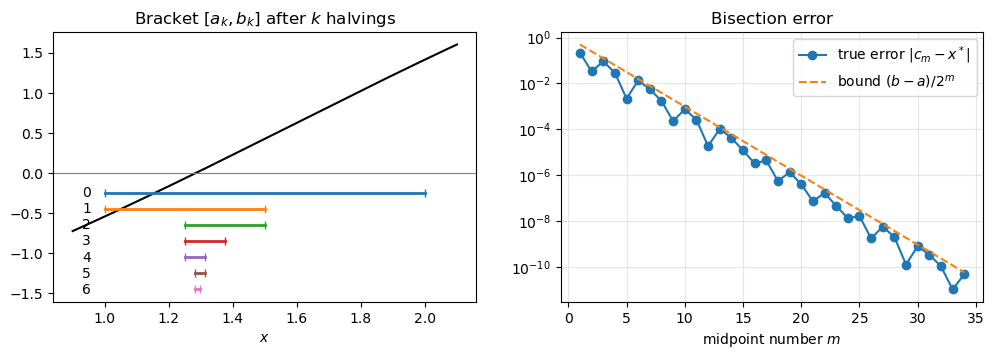

In [4]:
def f1(x):
    return x - np.cos(x) - 1

a, b, tol = 1.0, 2.0, 1e-10
print(f"f({a}) = {f1(a):.3f},  f({b}) = {f1(b):.3f}")

root, mids, brackets = bisection(f1, a, b, tol=tol)
x_star = optimize.brentq(f1, a, b, xtol=1e-15)      # accurate reference root

print(f"root ≈ {root:.12f}   ({len(mids)} midpoints)")
print(f"predicted number of midpoints: m > log2((b-a)/tol) = {np.log2((b - a) / tol):.2f}")
print(f"true error |c - x*| = {abs(root - x_star):.2e}  (tol = {tol})")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
xx = np.linspace(0.9, 2.1, 300)
ax[0].plot(xx, f1(xx), "k")
ax[0].axhline(0, color="gray", lw=0.8)
for k, (ak, bk) in enumerate(brackets[:7]):
    y = -0.25 - 0.2 * k
    ax[0].plot([ak, bk], [y, y], "|-", lw=2)
    ax[0].text(0.93, y, f"{k}", va="center")
ax[0].set_title("Bracket $[a_k, b_k]$ after $k$ halvings")
ax[0].set_xlabel("$x$")

m = np.arange(1, len(mids) + 1)
ax[1].semilogy(m, errors(mids, x_star), "o-", label=r"true error $|c_m - x^*|$")
ax[1].semilogy(m, (b - a) / 2.0**m, "--", label=r"bound $(b-a)/2^m$")
ax[1].set_xlabel("midpoint number $m$")
ax[1].set_title("Bisection error")
ax[1].grid(True, which="both", alpha=0.3); ax[1].legend()
plt.show()

**Tasks**
- Change `tol` and check that the number of midpoints agrees with the formula.
- The true error jumps up and down, while the bound decreases smoothly. Explain why using the left plot.

### Example 2.2: $f(x) = e^x - 5x + 2$ has two roots

A plot shows that there are two sign changes, so we need two brackets. Bisection finds *one* root per bracket.

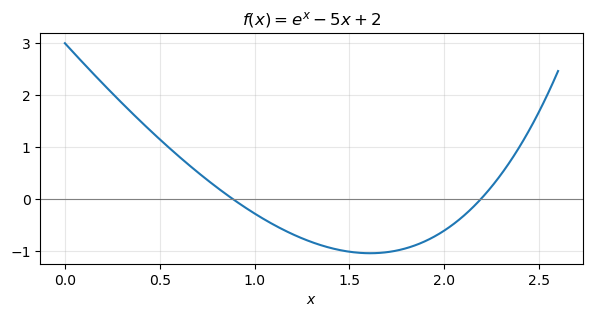

roots: 0.8842181389 and 2.1937416678


In [5]:
def f2(x):
    return np.exp(x) - 5 * x + 2

xx = np.linspace(0, 2.6, 300)
plt.figure(figsize=(7, 3))
plt.plot(xx, f2(xx)); plt.axhline(0, color="gray", lw=0.8)
plt.title("$f(x) = e^x - 5x + 2$"); plt.xlabel("$x$"); plt.grid(alpha=0.3)
plt.show()

r_small, _, _ = bisection(f2, 0.0, 1.5)
r_large, _, _ = bisection(f2, 1.5, 3.0)
print(f"roots: {r_small:.10f} and {r_large:.10f}")

### Example 2.3: which root does bisection find?

If the bracket contains several roots, the sign pattern decides which one we find, *not* which root is closest. Take $f(x) = \cos(\pi x)$, which has roots at $x = \pm\tfrac12, \tfrac32, \dots$, and three almost identical brackets.

In [6]:
def f3(x):
    return np.cos(np.pi * x)

for a0, b0 in [(-1.0, 2.0), (-0.9, 2.0), (-1.1, 2.0)]:
    c1 = (a0 + b0) / 2
    r, mids, _ = bisection(f3, a0, b0)
    print(f"[{a0:5.1f}, {b0}]: first midpoint {c1:5.2f}, sign f(a) = {np.sign(f3(a0)):+.0f}, "
          f"sign f(c1) = {np.sign(f3(c1)):+.0f}  ->  root {r:.6f}  ({len(mids)} midpoints)")

[ -1.0, 2.0]: first midpoint  0.50, sign f(a) = -1, sign f(c1) = +1  ->  root -0.500000  (35 midpoints)
[ -0.9, 2.0]: first midpoint  0.55, sign f(a) = -1, sign f(c1) = -1  ->  root 1.500000  (35 midpoints)
[ -1.1, 2.0]: first midpoint  0.45, sign f(a) = -1, sign f(c1) = +1  ->  root -0.500000  (35 midpoints)


**Tasks**
- Explain the output. Which step decides which root is found?
- For $[-1, 2]$ the first midpoint $x = 0.5$ *is* a root, yet bisection returns $-0.5$! Explain. *Hint:* print `f3(0.5)` and recall lecture 02 on floating-point numbers. What would happen with the stopping test $|f(c)| < \text{tol}$ instead?
- Bisection can never find the root of $f(x) = (x-1)^2$. Why?

## 3 Fixed-point iteration

A **fixed point** of $g$ is a number $x^*$ with $x^* = g(x^*)$. **Fixed-point iteration** is
$$
x_{n+1} = g(x_n), \qquad n = 0, 1, 2, \dots
$$
Any equation $f(x) = 0$ can be rewritten as $x = g(x)$ in *many* ways, for example $g(x) = x - f(x)$ or $g(x) = x - f(x)/f'(x)$. As we will see, the choice of $g$ decides everything.

**Why the derivative matters.** Since $x^* = g(x^*)$, the mean value theorem gives
$$
x_{n+1} - x^* = g(x_n) - g(x^*) = g'(\xi_n)\,(x_n - x^*)
$$
for some $\xi_n$ between $x_n$ and $x^*$. The error is multiplied by $g'(\xi_n)$ in each step, which motivates the following two theorems.

**Theorem 3.1 (contraction).** Let $g$ be continuously differentiable on $[a,b]$ with

1. $g(x) \in [a,b]$ for all $x \in [a,b]$ ($g$ maps the interval into itself), and
2. $|g'(x)| \le k$ for all $x \in [a,b]$, with a constant $0 \le k < 1$.

Then $g$ has exactly one fixed point $x^*$ in $[a,b]$, the iteration converges to $x^*$ for **every** $x_0 \in [a,b]$, and
$$
|x_n - x^*| \le k^n |x_0 - x^*|, \qquad
|x_n - x^*| \le \frac{k^n}{1-k}\,|x_1 - x_0|, \qquad
|x_n - x^*| \le \frac{k}{1-k}\,|x_n - x_{n-1}|.
$$

**Theorem 3.2 (local convergence).** Let $g$ be continuously differentiable near a fixed point $x^*$.

- If $|g'(x^*)| < 1$, the iteration converges for all $x_0$ close enough to $x^*$, and
  $$\frac{e_{n+1}}{e_n} \to |g'(x^*)|,$$
  i.e. convergence is **linear with $C = |g'(x^*)|$**. The smaller $|g'(x^*)|$, the faster.
- If $|g'(x^*)| > 1$, iterates starting near $x^*$ move *away* from it.
- If $g'(x^*) = 0$, convergence is faster than linear. This is the key to Newton's method (Section 4).

The sign of $g'(x^*)$ determines how the iterates approach $x^*$: $g' > 0$ gives a monotone "staircase", $g' < 0$ gives an oscillating "spiral". This is easy to see in a **cobweb plot**: from $(x_n, 0)$ go vertically to the graph of $g$, then horizontally to the line $y = x$, and repeat.

In [7]:
def fixed_point(g, x0, tol=1e-10, max_iter=200):
    # Returns the last iterate and the list of iterates (including x0).
    xs = [x0]
    for _ in range(max_iter):
        x_new = g(xs[-1])
        xs.append(x_new)
        if not np.isfinite(x_new):
            print("fixed_point: iterates are no longer finite (diverged)")
            break
        if abs(x_new - xs[-2]) < tol:
            break
    return xs[-1], xs

def plot_cobweb(g, x0, n_steps, xlim, ax=None, title=None):
    # Cobweb diagram for x_{n+1} = g(x_n)
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))
    xx = np.linspace(*xlim, 400)
    with np.errstate(all="ignore"):
        ax.plot(xx, g(xx), "k", lw=2, label="$y = g(x)$")
    ax.plot(xx, xx, color="gray", lw=1, label="$y = x$")
    x = x0
    px, py = [x0], [0.0]
    with np.errstate(all="ignore"):
        for _ in range(n_steps):
            y = g(x)
            if not np.isfinite(y):
                break
            px += [x, y]
            py += [y, y]
            x = y
    ax.plot(px, py, "b-", lw=1, alpha=0.8)
    ax.plot(x0, 0, "ro")
    ax.set_xlim(*xlim); ax.set_ylim(*xlim); ax.set_aspect("equal")
    ax.set_xlabel("$x$")
    if title:
        ax.set_title(title)
    ax.legend(loc="upper left", fontsize=8)
    return ax

### Example 3.1: three rewritings of $e^x - 5x + 2 = 0$

| rewriting | $g(x)$ | $g'(x)$ |
|---|---|---|
| $5x = e^x + 2$ | $g_1(x) = (e^x+2)/5$ | $g_1'(x) = e^x/5$ |
| $x = x + (e^x - 5x + 2)$ | $g_2(x) = e^x - 4x + 2$ | $g_2'(x) = e^x - 4$ |
| $e^x = 5x - 2$ | $g_3(x) = \ln(5x-2)$ | $g_3'(x) = 5/(5x-2)$, for $x > 0.4$ |

All three have the same fixed points: the roots found in Example 2.2. Theorem 3.2 lets us **predict** the behaviour by evaluating $|g'|$ at each root.

In [8]:
def g1(x): return (np.exp(x) + 2) / 5
def g2(x): return np.exp(x) - 4 * x + 2
def g3(x): return np.log(5 * x - 2)
def dg1(x): return np.exp(x) / 5
def dg2(x): return np.exp(x) - 4
def dg3(x): return 5 / (5 * x - 2)

gs = {"g1": (g1, dg1), "g2": (g2, dg2), "g3": (g3, dg3)}

table = pd.DataFrame({
    name: {f"|g'(x*)| at x* = {r_small:.4f}": abs(dg(r_small)),
           f"|g'(x*)| at x* = {r_large:.4f}": abs(dg(r_large))}
    for name, (g, dg) in gs.items()
}).T
print(table.to_string(float_format="{:.3f}".format))

    |g'(x*)| at x* = 0.8842  |g'(x*)| at x* = 2.1937
g1                    0.484                    1.794
g2                    1.579                    4.969
g3                    2.065                    0.557


**Prediction:** $g_1$ can only converge to the small root, $g_3$ only to the large root, and $g_2$ to neither. Let us check this, starting from $x_0 = 2.2$ (as in the book) and $x_0 = 1.0$.

fixed_point: iterates are no longer finite (diverged)
fixed_point: iterates are no longer finite (diverged)
        x0   g  converged  last iterate  iterations
0 2.200000  g1      False           inf          12
1 2.200000  g2      False           inf           6
2 2.200000  g3       True      2.193742          31
3 1.000000  g1       True      0.884218          30
4 1.000000  g2      False      1.108061         100
5 1.000000  g3       True      2.193742          43


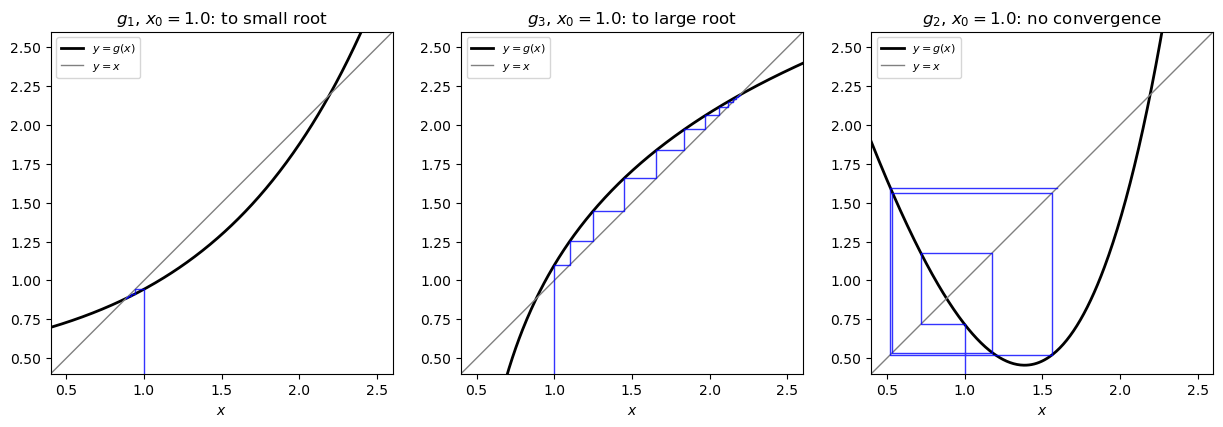

In [9]:
rows = []
for x0 in [2.2, 1.0]:
    for name, (g, dg) in gs.items():
        with np.errstate(all="ignore"):
            x, xs = fixed_point(g, x0, tol=1e-10, max_iter=100)
        ok = np.isfinite(x) and abs(x - g(x)) < 1e-8
        rows.append({"x0": x0, "g": name, "converged": ok,
                     "last iterate": x, "iterations": len(xs) - 1})
print(pd.DataFrame(rows).to_string(float_format="{:.6f}".format))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_cobweb(g1, 1.0, 15, (0.4, 2.6), axes[0], "$g_1$, $x_0=1.0$: to small root")
plot_cobweb(g3, 1.0, 15, (0.4, 2.6), axes[1], "$g_3$, $x_0=1.0$: to large root")
plot_cobweb(g2, 1.0, 6, (0.4, 2.6), axes[2], "$g_2$, $x_0=1.0$: no convergence")
plt.show()

Theorem 3.2 predicts not only *whether* it converges but also *how fast*: the error ratio $e_{n+1}/e_n$ should approach $|g'(x^*)|$.

g1: last error ratios [0.4842 0.4842 0.4842 0.4842 0.4842],  |g1'(x*)| = 0.4842
g3: last error ratios [0.5613 0.5596 0.5587 0.5582 0.5579],  |g3'(x*)| = 0.5575


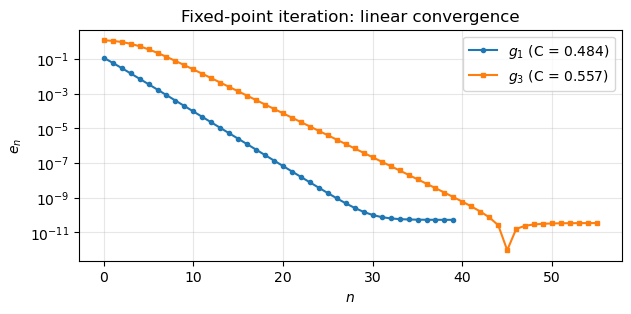

In [10]:
_, xs1 = fixed_point(g1, 1.0, tol=1e-13)
_, xs3 = fixed_point(g3, 1.0, tol=1e-13)
r1 = errors(xs1, r_small); r3 = errors(xs3, r_large)

print(f"g1: last error ratios {np.round(r1[11:16] / r1[10:15], 4)},  |g1'(x*)| = {dg1(r_small):.4f}")
print(f"g3: last error ratios {np.round(r3[11:16] / r3[10:15], 4)},  |g3'(x*)| = {dg3(r_large):.4f}")

plt.figure(figsize=(7, 3))
plt.semilogy(r1, "o-", ms=3, label=f"$g_1$ (C = {dg1(r_small):.3f})")
plt.semilogy(r3, "s-", ms=3, label=f"$g_3$ (C = {dg3(r_large):.3f})")
plt.xlabel("$n$"); plt.ylabel("$e_n$"); plt.title("Fixed-point iteration: linear convergence")
plt.grid(True, which="both", alpha=0.3); plt.legend(); plt.show()

**Tasks**
- Use $C = |g_3'(x^*)|$ and $e_0 \approx 1.2$ to predict how many iterations $g_3$ needs to reach $e_n < 10^{-10}$. Compare with the plot.
- Try $x_0 = 1.9, 0.9, 0.6$ for all three functions. Explain each result from the table of $|g'(x^*)|$. (What happens to $g_3$ when $5x - 2 \le 0$?)

### Example 3.2: $x = \cos x + 1$, a slow, oscillating iteration

This is the same equation as in Example 2.1. Here $g'(x) = -\sin x$, and $g'(x^*) \approx -0.96$: the iteration converges (since $|g'(x^*)| < 1$) but very slowly, and it oscillates because $g'(x^*) < 0$.

g'(x*) = -0.9590
fixed point 1.2834287418 after 545 iterations (bisection needed 35)


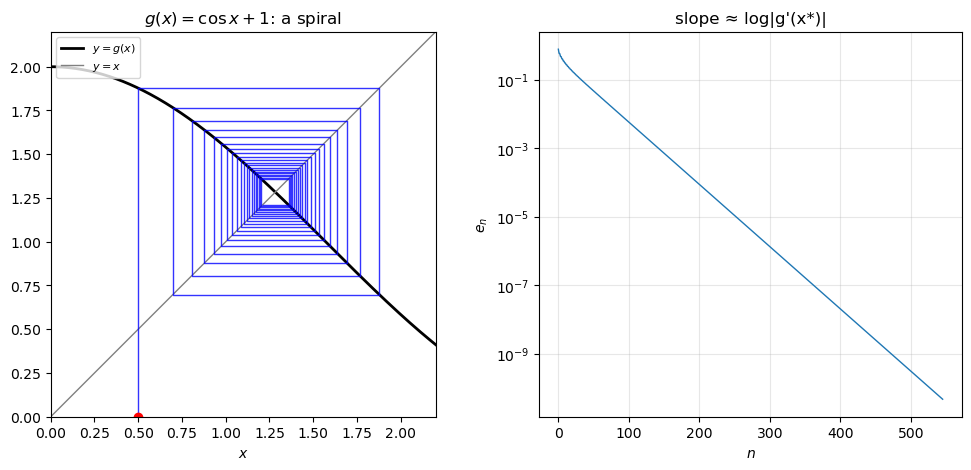

In [11]:
def g_cos(x):
    return np.cos(x) + 1

x, xs = fixed_point(g_cos, 0.5, tol=1e-10, max_iter=2000)
print(f"g'(x*) = {-np.sin(x_star):.4f}")
print(f"fixed point {x:.10f} after {len(xs) - 1} iterations (bisection needed {len(mids)})")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
plot_cobweb(g_cos, 0.5, 40, (0.0, 2.2), ax[0], r"$g(x) = \cos x + 1$: a spiral")
ax[1].semilogy(errors(xs, x_star), lw=1)
ax[1].set_xlabel("$n$"); ax[1].set_ylabel("$e_n$"); ax[1].set_title("slope ≈ log|g'(x*)|")
ax[1].grid(True, which="both", alpha=0.3)
plt.show()

### Going further: the logistic map

Fixed-point iterations are also *models*. The logistic map
$$
x_{n+1} = r\,x_n(1 - x_n), \qquad 0 \le x_n \le 1,
$$
models a population with growth rate $r$. Its nonzero fixed point is $x^* = 1 - 1/r$ with $g'(x^*) = 2 - r$, so it is stable exactly when $1 < r < 3$. For $r > 3$ the fixed point becomes unstable: the iterates settle into a 2-cycle, then a 4-cycle, … and around $r \approx 3.57$ they become **chaotic**.

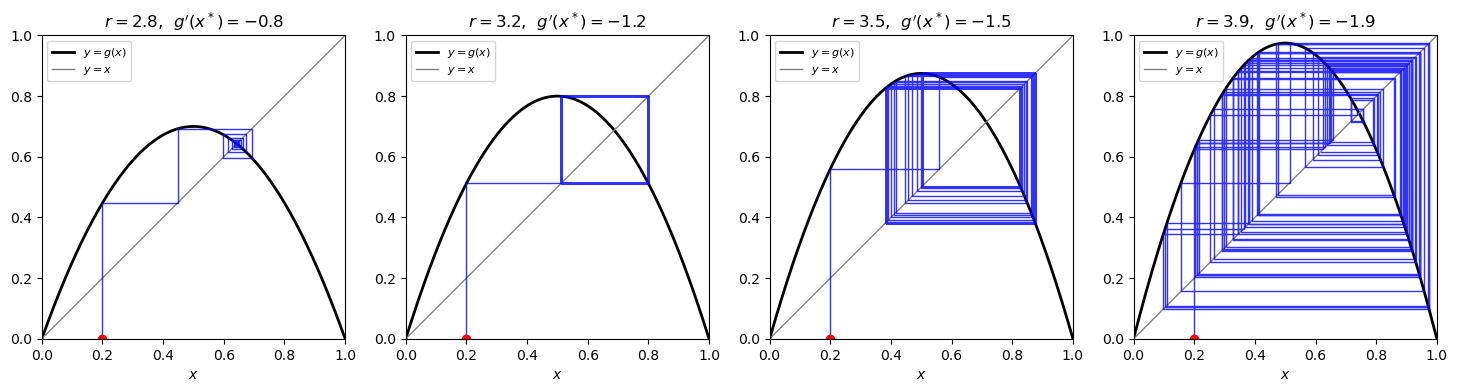

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, r in zip(axes, [2.8, 3.2, 3.5, 3.9]):
    plot_cobweb(lambda x, r=r: r * x * (1 - x), 0.2, 80, (0, 1), ax,
                f"$r = {r}$,  $g'(x^*) = {2 - r:.1f}$")
plt.show()

In [ ]:
# Optional: interactive version (requires ipywidgets)
try:
    from ipywidgets import interact, FloatSlider, IntSlider
    def cobweb_logistic(r=2.8, x0=0.2, n=20):
        plot_cobweb(lambda x: r * x * (1 - x), x0, n, (0, 1), title=f"$r = {r:.3f}$")
        plt.show()
    interact(cobweb_logistic,
             r=FloatSlider(min=0.5, max=4.0, step=0.01, value=2.8, continuous_update=False),
             x0=FloatSlider(min=0.01, max=0.99, step=0.01, value=0.2, continuous_update=False),
             n=IntSlider(min=1, max=200, value=20, continuous_update=False))
except ImportError:
    print("ipywidgets is not installed")

interactive(children=(FloatSlider(value=2.8, continuous_update=False, description='r', max=4.0, min=0.5, step=…

## 4 Newton's method

**Derivation.** Near the current iterate $x_n$ we replace $f$ by its tangent line (first-order Taylor polynomial):
$$
f(x_n + h) \approx f(x_n) + f'(x_n)\,h.
$$
Setting the right-hand side to zero gives $h = -f(x_n)/f'(x_n)$, so
$$
\boxed{\,x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}\,}
$$
Geometrically, $x_{n+1}$ is where the tangent line at $(x_n, f(x_n))$ crosses the $x$-axis.

**Newton as a fixed-point iteration.** Newton's method is $x_{n+1} = g(x_n)$ with $g(x) = x - f(x)/f'(x)$. The quotient rule gives
$$
g'(x) = \frac{f(x)\,f''(x)}{f'(x)^2}, \qquad\text{so}\qquad g'(x^*) = 0 \quad\text{if } f'(x^*) \ne 0.
$$
By Theorem 3.2 this is faster than linear.

**Theorem 4.1 (quadratic convergence).** Let $f$ be twice continuously differentiable, $f(x^*) = 0$ and $f'(x^*) \ne 0$. Then Newton's method converges for all $x_0$ sufficiently close to $x^*$, and
$$
\frac{e_{n+1}}{e_n^2} \to \left|\frac{f''(x^*)}{2f'(x^*)}\right| .
$$

*Proof sketch.* Taylor expansion about $x_n$ with remainder gives $0 = f(x^*) = f(x_n) + f'(x_n)(x^* - x_n) + \tfrac12 f''(\xi_n)(x^* - x_n)^2$. Dividing by $f'(x_n)$ and using the Newton formula,
$$
x_{n+1} - x^* = \frac{f''(\xi_n)}{2f'(x_n)}\,(x_n - x^*)^2 .
$$

**Caveats.** The theorem is *local*: far from the root Newton can diverge. It requires $f'$, and it has trouble when $f'$ is small near the iterates. At a multiple root ($f'(x^*) = 0$) convergence is only linear.

In [14]:
def newton(f, df, x0, tol=1e-12, max_iter=50, warn=True):
    # Returns the last iterate and the list of iterates (including x0).
    xs = [x0]
    for _ in range(max_iter):
        x = xs[-1]
        fx = f(x)
        if fx == 0:                       # hit the root exactly
            return x, xs
        dfx = df(x)
        if dfx == 0:
            raise ZeroDivisionError(f"f'(x) = 0 at x = {x}")
        xs.append(x - fx / dfx)
        if abs(xs[-1] - x) < tol:
            return xs[-1], xs
    if warn:
        print("newton: max_iter reached without convergence")
    return xs[-1], xs

### Example 4.1: square roots

To compute $\sqrt{c}$ we solve $f(x) = x^2 - c = 0$. Newton's method gives
$$
x_{n+1} = x_n - \frac{x_n^2 - c}{2x_n} = \frac12\left(x_n + \frac{c}{x_n}\right),
$$
the ancient *Babylonian (Heron's) method*. Here $|f''/(2f')| = 1/(2\sqrt c)$ at the root.

In [15]:
c = 3.0
x0 = 0.5
x, xs_newton = newton(lambda x: x**2 - c, lambda x: 2 * x, x0)
e = errors(xs_newton, np.sqrt(c))

tab = pd.DataFrame({"x_n": xs_newton, "e_n": e})
tab["correct digits"] = np.clip(-np.log10(np.maximum(e, 1e-17)), 0, 16).round(1)
tab["e_n / e_(n-1)^2"] = np.r_[np.nan, e[1:] / e[:-1]**2]
print(tab.to_string(formatters={"x_n": "{:.15f}".format, "correct digits": "{:.1f}".format}))
print(f"\ntheory: e_(n+1)/e_n^2 -> 1/(2 sqrt(c)) = {1 / (2 * np.sqrt(c)):.4f}")
print("estimated orders:", np.round(estimate_order(xs_newton, np.sqrt(c)), 3))

                x_n       e_n correct digits  e_n / e_(n-1)^2
0 0.500000000000000 1.232e+00            0.0              NaN
1 3.250000000000000 1.518e+00            0.0        1.000e+00
2 2.086538461538462 3.545e-01            0.5        1.538e-01
3 1.762163239985821 3.011e-02            1.5        2.396e-01
4 1.732308093206635 2.573e-04            3.6        2.837e-01
5 1.732050826675149 1.911e-08            7.7        2.886e-01
6 1.732050807568877 2.220e-16           15.7        6.083e-01
7 1.732050807568877 0.000e+00           16.0        0.000e+00

theory: e_(n+1)/e_n^2 -> 1/(2 sqrt(c)) = 0.2887
estimated orders: [-6.97   1.695  1.931  1.996]


The first order estimates are meaningless: the asymptotic behaviour only sets in once we are close to the root. Note also that the first step *moves away* from the root: at $x_0 = 0.5$ the tangent is flat, so it lands at $x_1 = 3.25$. After that, the number of correct digits roughly doubles every step.

Compare with bisection on $[0, 3]$:

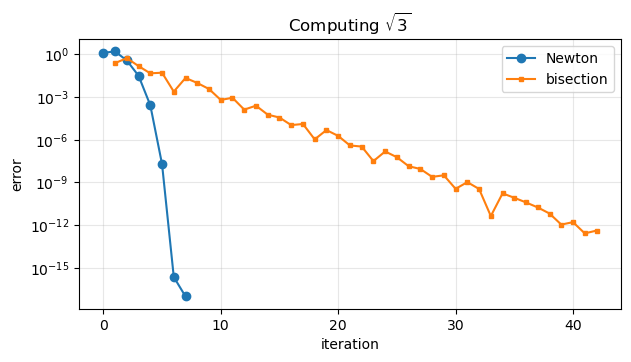

In [16]:
_, mids_sqrt, _ = bisection(lambda x: x**2 - c, 0.0, 3.0, tol=1e-12)

plt.figure(figsize=(7, 3.5))
plt.semilogy(errors(xs_newton, np.sqrt(c)) + 1e-17, "o-", label="Newton")
plt.semilogy(np.arange(1, len(mids_sqrt) + 1), errors(mids_sqrt, np.sqrt(c)) + 1e-17, "s-", ms=3,
             label="bisection")
plt.xlabel("iteration"); plt.ylabel("error"); plt.title(r"Computing $\sqrt{3}$")
plt.grid(True, which="both", alpha=0.3); plt.legend(); plt.show()

### Example 4.2: Newton can diverge

Solve $\tan^{-1}(x-1) = \tfrac12$, i.e.
$$
f(x) = \tan^{-1}(x-1) - \tfrac12, \qquad f'(x) = \frac{1}{1 + (x-1)^2}, \qquad x^* = 1 + \tan\tfrac12 \approx 1.546.
$$
The derivative becomes small when $|x - 1|$ is large, so the tangent is nearly flat and the Newton step becomes huge. Starting from $x_0 = 2$ works; starting from $x_0 = 4.2$ does not.

x0 = 2.0: 2, 1.429, 1.541, 1.546, 1.546, 1.546
x0 = 4.2: 4.2, -4.431, 53.17, -2810, 1.636e+07, -2.867e+14


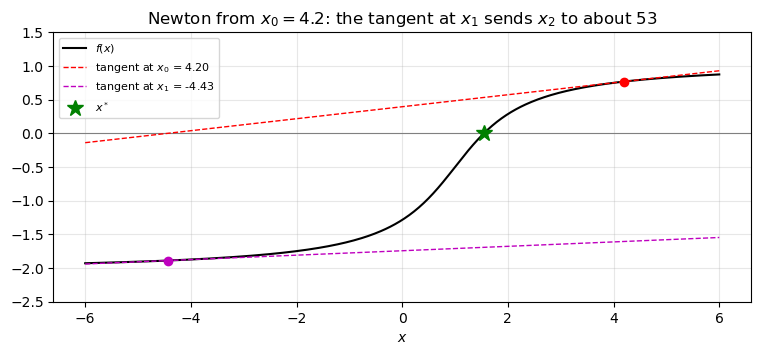

In [17]:
def f_atan(x):  return np.arctan(x - 1) - 0.5
def df_atan(x): return 1 / (1 + (x - 1)**2)
x_star_atan = 1 + np.tan(0.5)

for x0 in [2.0, 4.2]:
    _, xs = newton(f_atan, df_atan, x0, max_iter=5, warn=False)
    print(f"x0 = {x0}:", ", ".join(f"{v:.4g}" for v in xs))

_, xs = newton(f_atan, df_atan, 4.2, max_iter=2, warn=False)
xx = np.linspace(-6, 6, 400)
plt.figure(figsize=(9, 3.5))
plt.plot(xx, f_atan(xx), "k", label="$f(x)$")
plt.axhline(0, color="gray", lw=0.8)
for k, color in [(0, "r"), (1, "m")]:
    xk = xs[k]
    plt.plot(xx, f_atan(xk) + df_atan(xk) * (xx - xk), color + "--", lw=1,
             label=f"tangent at $x_{k}$ = {xk:.2f}")
    plt.plot(xk, f_atan(xk), color + "o")
plt.plot(x_star_atan, 0, "g*", ms=12, label="$x^*$")
plt.ylim(-2.5, 1.5); plt.xlabel("$x$"); plt.grid(alpha=0.3); plt.legend(fontsize=8)
plt.title("Newton from $x_0 = 4.2$: the tangent at $x_1$ sends $x_2$ to about 53")
plt.show()

**Task.** Find (numerically) the largest $x_0 > x^*$ for which Newton converges. *Hint:* try a grid of starting values. What happens exactly at the boundary?

### Example 4.3: multiple roots slow Newton down

$f(x) = (x-1)^2(x+2)$ has a **double root** at $x = 1$, where $f'(1) = 0$. Theorem 4.1 does not apply. One can show that for a root of multiplicity $m$, Newton converges only *linearly* with $C = 1 - 1/m$ (here $C = 1/2$).

If $m$ is known, the **modified Newton method** $x_{n+1} = x_n - m\,f(x_n)/f'(x_n)$ restores quadratic convergence.

plain Newton, e_(n+1)/e_n: [0.5556 0.5362 0.5216 0.512  0.5064 0.5033 0.5017]
plain Newton: 41 iterations, modified Newton: 5 iterations


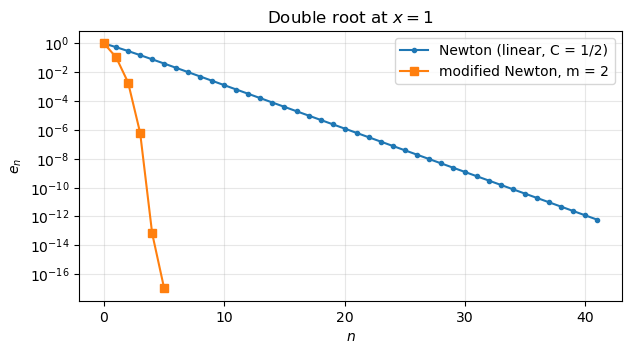

In [18]:
def f_double(x):  return (x - 1)**2 * (x + 2)
def df_double(x): return 2 * (x - 1) * (x + 2) + (x - 1)**2

_, xs_plain = newton(f_double, df_double, 2.0, tol=1e-12, max_iter=100)
# modified Newton with m = 2: pass f'/2 as the "derivative" so the step becomes 2 f/f'
_, xs_mod = newton(f_double, lambda x: df_double(x) / 2, 2.0, tol=1e-12)

e_plain = errors(xs_plain, 1.0)
print("plain Newton, e_(n+1)/e_n:", np.round(e_plain[1:8] / e_plain[:7], 4))
print(f"plain Newton: {len(xs_plain) - 1} iterations, modified Newton: {len(xs_mod) - 1} iterations")

plt.figure(figsize=(7, 3.5))
plt.semilogy(e_plain + 1e-17, "o-", ms=3, label="Newton (linear, C = 1/2)")
plt.semilogy(errors(xs_mod, 1.0) + 1e-17, "s-", label="modified Newton, m = 2")
plt.xlabel("$n$"); plt.ylabel("$e_n$"); plt.title("Double root at $x = 1$")
plt.grid(True, which="both", alpha=0.3); plt.legend(); plt.show()

**Task.** Replace `f_double` by the expanded form $x^3 - 3x + 2$ (same function!) and rerun. Why can you no longer get the error below about $10^{-8}$? *Hint:* near $x = 1$, $f(x) \approx 3(x-1)^2$; compare its size with the round-off error in evaluating $x^3 - 3x + 2$ (see lecture 02 on floating-point numbers).

## 5 Newton's method for systems

Now $\mathbf F : \mathbb R^n \to \mathbb R^n$ and we want $\mathbf F(\mathbf x) = \mathbf 0$. The same idea works: linearise around $\mathbf x_k$,
$$
\mathbf F(\mathbf x_k + \mathbf h) \approx \mathbf F(\mathbf x_k) + J(\mathbf x_k)\,\mathbf h,
\qquad J_{ij} = \frac{\partial F_i}{\partial x_j},
$$
and set the right-hand side to zero. Each Newton step is therefore

1. solve the **linear system** $J(\mathbf x_k)\,\mathbf h = -\mathbf F(\mathbf x_k)$ (lecture 06),
2. update $\mathbf x_{k+1} = \mathbf x_k + \mathbf h$.

We never compute $J^{-1}$; we solve the system with `np.linalg.solve`. If $J(\mathbf x^*)$ is nonsingular, convergence is again locally quadratic.

In [19]:
def newton_system(F, J, x0, tol=1e-12, max_iter=50):
    # Returns the last iterate and the list of iterates (including x0).
    xs = [np.array(x0, dtype=float)]
    for _ in range(max_iter):
        x = xs[-1]
        h = np.linalg.solve(J(x), -F(x))
        xs.append(x + h)
        if np.linalg.norm(h) < tol:
            return xs[-1], xs
    print("newton_system: max_iter reached without convergence")
    return xs[-1], xs

### Example 5.1: intersections of an ellipse and a curve

Find all intersections of the ellipse $4x^2 + y^2 = 4$ and the curve $x^2y^3 = 1$:
$$
\mathbf F(x,y) = \begin{bmatrix} 4x^2 + y^2 - 4 \\ x^2y^3 - 1 \end{bmatrix}, \qquad
J(x,y) = \begin{bmatrix} 8x & 2y \\ 2xy^3 & 3x^2y^2 \end{bmatrix}.
$$
Newton finds *one* solution per starting point, so we first **plot** the zero contours to see how many solutions there are and where to start. Since $\mathbf F$ depends on $x$ only through $x^2$, the solutions come in pairs $(\pm x, y)$, and $x^2y^3 = 1$ forces $y > 0$.

start (1.0, 1.0): solution ( 0.82168163, 1.13989352) after 6 steps, |F| = 0.0e+00
start (0.4, 1.9): solution ( 0.40414946, 1.82938593) after 4 steps, |F| = 9.2e-16
start (-1.0, 1.0): solution (-0.82168163, 1.13989352) after 6 steps, |F| = 0.0e+00
start (-0.4, 1.9): solution (-0.40414946, 1.82938593) after 4 steps, |F| = 9.2e-16

|F(x_k)| from (1, 1): 1.0e+00, 1.1e-01, 4.8e-03, 1.3e-05, 8.8e-11, 5.0e-16, 0.0e+00


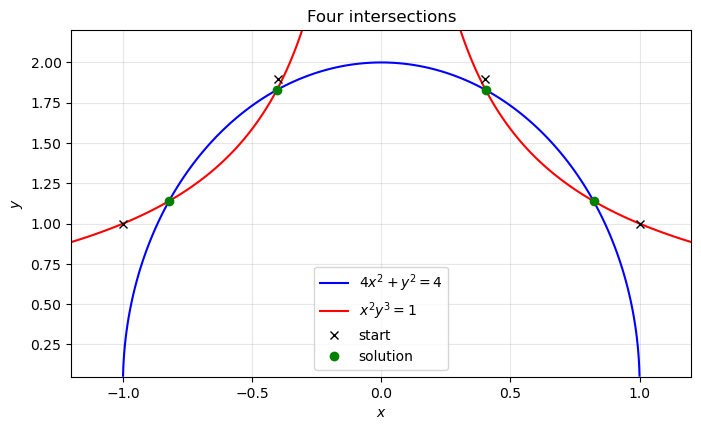

In [20]:
def F_ell(v):
    x, y = v
    return np.array([4 * x**2 + y**2 - 4, x**2 * y**3 - 1])

def J_ell(v):
    x, y = v
    return np.array([[8 * x, 2 * y],
                     [2 * x * y**3, 3 * x**2 * y**2]])

starts = [(1.0, 1.0), (0.4, 1.9), (-1.0, 1.0), (-0.4, 1.9)]
solutions = []
for s in starts:
    sol, hist = newton_system(F_ell, J_ell, s)
    solutions.append(sol)
    print(f"start {s}: solution ({sol[0]: .8f}, {sol[1]:.8f}) after {len(hist) - 1} steps, "
          f"|F| = {np.linalg.norm(F_ell(sol)):.1e}")

_, hist = newton_system(F_ell, J_ell, (1.0, 1.0))
print("\n|F(x_k)| from (1, 1):", ", ".join(f"{np.linalg.norm(F_ell(v)):.1e}" for v in hist))

X, Y = np.meshgrid(np.linspace(-1.2, 1.2, 400), np.linspace(0.05, 2.2, 400))
plt.figure(figsize=(8, 4.5))
plt.contour(X, Y, 4 * X**2 + Y**2 - 4, levels=[0], colors="b")
plt.contour(X, Y, X**2 * Y**3 - 1, levels=[0], colors="r")
for s, sol in zip(starts, solutions):
    plt.plot(*s, "kx"); plt.plot(*sol, "go")
plt.plot([], [], "b", label="$4x^2 + y^2 = 4$"); plt.plot([], [], "r", label="$x^2y^3 = 1$")
plt.plot([], [], "kx", label="start"); plt.plot([], [], "go", label="solution")
plt.xlabel("$x$"); plt.ylabel("$y$"); plt.legend(loc="lower center"); plt.grid(alpha=0.3)
plt.title("Four intersections"); plt.show()

**Tasks**
- The printed $\|\mathbf F\|$ values show quadratic convergence. How can you tell?
- What happens if you start at $(0, 1)$? Look at $J(0, y)$.

## 6 Newton's method for optimisation

At a minimum of a smooth function $f : \mathbb R^n \to \mathbb R$ the gradient vanishes, $\nabla f(\mathbf x^*) = \mathbf 0$. This is a nonlinear system, so we apply Section 5 with
$$
\mathbf F = \nabla f, \qquad J = H_f \quad (\text{the Hessian matrix of second derivatives}).
$$
The Newton step solves $H_f(\mathbf x_k)\,\mathbf h = -\nabla f(\mathbf x_k)$.

**Important:** Newton finds **stationary points**, and those can be minima, maxima or saddle points. Afterwards, check that the Hessian is positive definite, i.e. that all its eigenvalues are positive (lecture 07).

### Example 6.1: the Rosenbrock function
$$
f(x, y) = (1-x)^2 + 100\,(y - x^2)^2
$$
has its only minimum at $(1,1)$, at the bottom of a narrow, curved valley. Methods that only use the gradient zig-zag slowly along such a valley; Newton uses the curvature (the Hessian) and gets there in a few steps.
$$
\nabla f = \begin{bmatrix} -2(1-x) - 400x(y - x^2) \\ 200(y - x^2) \end{bmatrix}, \qquad
H_f = \begin{bmatrix} 2 - 400y + 1200x^2 & -400x \\ -400x & 200 \end{bmatrix}.
$$

minimum at [1. 1.] after 8 steps, f = 0.0e+00
eigenvalues of the Hessian there: [3.993608e-01 1.001601e+03] -> a minimum


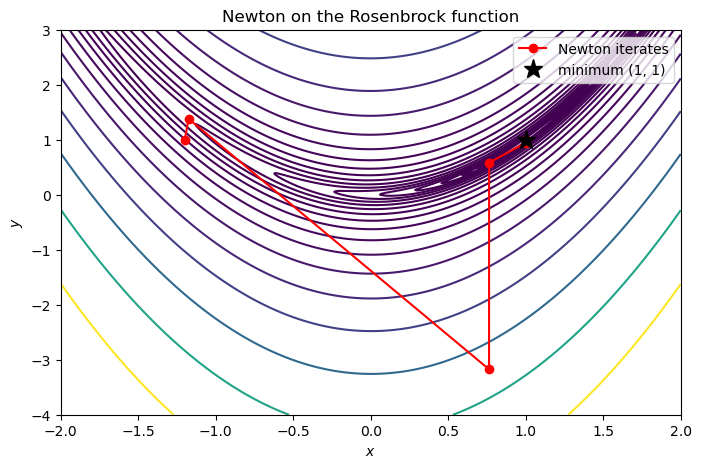

In [21]:
def rosen(v):
    x, y = v
    return (1 - x)**2 + 100 * (y - x**2)**2

def grad_rosen(v):
    x, y = v
    return np.array([-2 * (1 - x) - 400 * x * (y - x**2), 200 * (y - x**2)])

def hess_rosen(v):
    x, y = v
    return np.array([[2 - 400 * y + 1200 * x**2, -400 * x],
                     [-400 * x, 200.0]])

x_min, path = newton_system(grad_rosen, hess_rosen, (-1.2, 1.0))
path = np.array(path)
print(f"minimum at {x_min} after {len(path) - 1} steps, f = {rosen(x_min):.1e}")
print("eigenvalues of the Hessian there:", np.linalg.eigvalsh(hess_rosen(x_min)), "-> a minimum")

X, Y = np.meshgrid(np.linspace(-2, 2, 400), np.linspace(-4, 3, 400))
plt.figure(figsize=(8, 5))
plt.contour(X, Y, rosen((X, Y)), levels=np.logspace(-1, 3.5, 20), cmap="viridis")
plt.plot(path[:, 0], path[:, 1], "ro-", label="Newton iterates")
plt.plot(1, 1, "k*", ms=14, label="minimum (1, 1)")
plt.xlabel("$x$"); plt.ylabel("$y$"); plt.legend(); plt.title("Newton on the Rosenbrock function")
plt.show()

### Example 6.2: Newton does not know it should minimise

$f(x,y) = \tfrac14x^4 - \tfrac12x^2 + \tfrac12y^2$ has minima at $(\pm1, 0)$ and a saddle point at $(0,0)$. Newton started at $(0.3, 0.5)$ converges to the saddle point.

In [22]:
grad_s = lambda v: np.array([v[0]**3 - v[0], v[1]])
hess_s = lambda v: np.array([[3 * v[0]**2 - 1, 0.0], [0.0, 1.0]])

for start in [(0.3, 0.5), (0.8, 0.5)]:
    p, _ = newton_system(grad_s, hess_s, start)
    print(f"start {start}: stationary point {np.round(p, 10)}, "
          f"Hessian eigenvalues {np.linalg.eigvalsh(hess_s(p))}")

start (0.3, 0.5): stationary point [0. 0.], Hessian eigenvalues [-1.  1.]
start (0.8, 0.5): stationary point [1. 0.], Hessian eigenvalues [1. 2.]


In practice, optimisation methods such as BFGS or trust-region methods (`scipy.optimize.minimize`) add safeguards that make sure $f$ decreases in every step.

## 7 The secant method

Newton needs $f'$. If the derivative is unavailable or expensive, replace it by the slope of the secant through the last two iterates:
$$
f'(x_n) \approx \frac{f(x_n) - f(x_{n-1})}{x_n - x_{n-1}}
\quad\Longrightarrow\quad
x_{n+1} = x_n - f(x_n)\,\frac{x_n - x_{n-1}}{f(x_n) - f(x_{n-1})}.
$$

- It needs **two** starting values $x_0, x_1$. They do **not** have to bracket the root. (The *regula falsi* method keeps a bracket, but it is a different method and it can converge slowly.)
- It needs only **one new function evaluation per step**, because $f(x_{n-1})$ is reused.
- One can show that $e_{n+1} \approx C\,e_n e_{n-1}$. Inserting $e_{n+1} \approx K e_n^p$ gives $p^2 = p + 1$, so the order is the golden ratio
  $$p = \frac{1+\sqrt5}{2} \approx 1.618 \qquad (\text{superlinear}).$$
- Like Newton, it is only locally convergent, and it breaks down if $f(x_n) \approx f(x_{n-1})$.

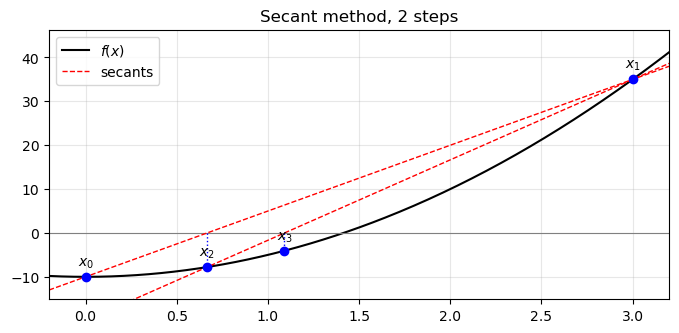

In [23]:
def secant(f, x0, x1, tol=1e-12, max_iter=50, warn=True):
    # Returns the last iterate and the list of iterates (including x0, x1).
    xs = [x0, x1]
    f0, f1 = f(x0), f(x1)
    for _ in range(max_iter):
        if f1 == f0:
            if f1 == 0:
                return xs[-1], xs
            raise ZeroDivisionError("f(x_n) = f(x_(n-1)): secant is horizontal")
        x2 = x1 - f1 * (x1 - x0) / (f1 - f0)
        xs.append(x2)
        if abs(x2 - x1) < tol:
            return x2, xs
        x0, f0 = x1, f1
        x1, f1 = x2, f(x2)
    if warn:
        print("secant: max_iter reached without convergence")
    return xs[-1], xs

def plot_secant(f, x0, x1, n_steps, xlim):
    _, xs = secant(f, x0, x1, max_iter=n_steps, warn=False)
    xs = xs[:n_steps + 2]
    xx = np.linspace(*xlim, 300)
    plt.figure(figsize=(8, 3.5))
    plt.plot(xx, f(xx), "k", label="$f(x)$"); plt.axhline(0, color="gray", lw=0.8)
    for i in range(len(xs) - 2):
        # the secant through (x_i, f(x_i)) and (x_{i+1}, f(x_{i+1})) crosses zero at x_{i+2}
        slope = (f(xs[i + 1]) - f(xs[i])) / (xs[i + 1] - xs[i])
        plt.plot(xx, f(xs[i + 1]) + slope * (xx - xs[i + 1]), "r--", lw=1,
                 label="secants" if i == 0 else None)
        plt.plot([xs[i + 2]] * 2, [0, f(xs[i + 2])], "b:", lw=1)
    plt.plot(xs, [f(x) for x in xs], "bo")
    for i, x in enumerate(xs):
        plt.annotate(f"$x_{i}$", (x, f(x)), textcoords="offset points", xytext=(0, 8), ha="center")
    fx = f(xx)
    plt.xlim(*xlim); plt.ylim(fx.min() - 0.1 * np.ptp(fx), fx.max() + 0.1 * np.ptp(fx))
    plt.grid(alpha=0.3); plt.legend(); plt.title(f"Secant method, {n_steps} steps"); plt.show()

plot_secant(lambda x: 5 * x**2 - 10, 0.0, 3.0, n_steps=2, xlim=(-0.2, 3.2))

Change `n_steps` above and make sure you understand each secant line.

The order on $x^2 - 3 = 0$:

In [24]:
_, xs_sec = secant(lambda x: x**2 - 3, 1.0, 2.0)
print("estimated orders:", np.round(estimate_order(xs_sec, np.sqrt(3)), 3))
print("golden ratio    :", (1 + np.sqrt(5)) / 2)

estimated orders: [1.403 1.855 1.51  1.667 1.6  ]
golden ratio    : 1.618033988749895


### Example 7.1: estimating a cooling constant (nonlinear least squares)

Newton's law of cooling says that a cup of coffee with initial temperature $T_0$ in a room at temperature $T_E$ cools as
$$
T(t) = T_E + (T_0 - T_E)\,e^{-kt}.
$$
Given measurements $(t_i, T_i)$ (Turner et al.), we want the $k$ that minimises the sum of squared errors
$$
C(k) = \frac12 \sum_{i} \bigl[T_E + (T_0 - T_E)e^{-kt_i} - T_i\bigr]^2 .
$$
Unlike in lecture 08, the model is **nonlinear** in the parameter $k$, so there are no normal equations. Instead we solve $C'(k) = 0$:
$$
C'(k) = \sum_i \bigl[T_E + (T_0 - T_E)e^{-kt_i} - T_i\bigr]\cdot\bigl[-(T_0 - T_E)\,t_i\,e^{-kt_i}\bigr] = 0 .
$$
$C''(k)$ is messy, so this is a natural job for the secant method. (The book has a misplaced parenthesis in $C'(k)$; the formula above is correct.)

k = 0.285086 per minute after 7 secant steps, C(k) = 6.7778


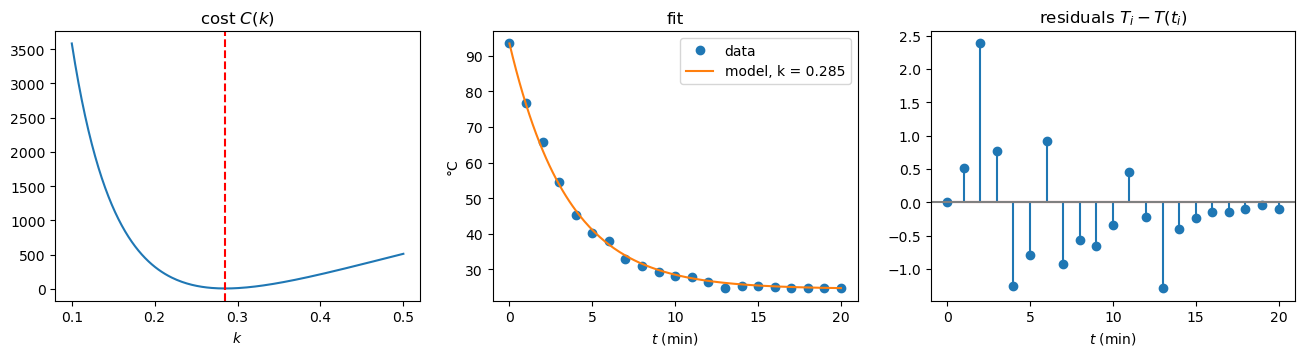

In [25]:
t = np.arange(21)
T_obs = np.array([93.50, 76.90, 65.90, 54.60, 45.30, 40.30, 37.90, 32.95, 30.99, 29.14, 28.14,
                  27.95, 26.54, 24.90, 25.38, 25.22, 25.07, 24.89, 24.81, 24.76, 24.63])
T0, TE = T_obs[0], 24.5

def model(t, k):
    return TE + (T0 - TE) * np.exp(-k * t)

def cost(k):
    return 0.5 * np.sum((model(t, k) - T_obs)**2)

def dcost(k):
    return np.sum((model(t, k) - T_obs) * (-(T0 - TE) * t * np.exp(-k * t)))

k_opt, ks = secant(dcost, 0.2, 0.3)
print(f"k = {k_opt:.6f} per minute after {len(ks) - 2} secant steps, C(k) = {cost(k_opt):.4f}")

fig, ax = plt.subplots(1, 3, figsize=(16, 3.5))
kk = np.linspace(0.1, 0.5, 200)
ax[0].plot(kk, [cost(k) for k in kk]); ax[0].axvline(k_opt, color="r", ls="--")
ax[0].set_xlabel("$k$"); ax[0].set_title("cost $C(k)$")
tt = np.linspace(0, 20, 200)
ax[1].plot(t, T_obs, "o", label="data"); ax[1].plot(tt, model(tt, k_opt), label=f"model, k = {k_opt:.3f}")
ax[1].set_xlabel("$t$ (min)"); ax[1].set_ylabel("°C"); ax[1].legend(); ax[1].set_title("fit")
ax[2].stem(t, T_obs - model(t, k_opt)); ax[2].axhline(0, color="gray")
ax[2].set_xlabel("$t$ (min)"); ax[2].set_title("residuals $T_i - T(t_i)$")
plt.show()

**Tasks**
- Look at the residuals. Are they random, or is there a pattern? What does that say about the model?
- Add random noise (e.g. `np.random.normal(0, 1, len(t))`) to `T_obs` and repeat. How much does $k$ change?
- Use only every second, or every fourth, measurement. How does $k$ change?
- Try other starting values for the secant method. When does it fail?
- *Harder:* estimate both $k$ and $T_E$. That requires solving $\nabla C = \mathbf 0$ in two unknowns, e.g. with `optimize.root` or `optimize.curve_fit`.

## 8 When should we stop?

An iteration never reaches $x^*$ exactly, so we need a **stopping criterion**. The common choices are:

| test | stops when | comment |
|---|---|---|
| step size | $\lvert x_{n+1} - x_n\rvert < \text{tol}$ | used by our fixed-point, Newton and secant codes |
| residual | $\lvert f(x_n)\rvert < \text{tol}$ | "how well is the equation satisfied?" |
| bracket width | $(b - a)/2 < \text{tol}$ | only for bracketing methods; a guaranteed error bound |

Relative versions ($\text{tol}\cdot|x_n|$) are better when $|x^*|$ is large or small. Always add a maximum number of iterations.

**The residual is not the error.** Near the root, $f(x_n) \approx f'(x^*)(x_n - x^*)$, so
$$
e_n \approx \frac{|f(x_n)|}{|f'(x^*)|}.
$$
If $f$ is flat ($|f'|$ small), a tiny residual can hide a large error.

**The step is not always the error either.** For superlinear methods the step is an excellent error estimate ($x_{n+1}$ is much closer to $x^*$ than $x_n$). For a linear method with rate $C$, Theorem 3.1 gives $e_n \le \frac{C}{1-C}|x_n - x_{n-1}|$. If $C \approx 1$ the factor is large, and the step *underestimates* the error.

In [26]:
# 1) Flat function: residual test accepts a poor approximation
f_flat = lambda x: 1e-6 * (x - 1)          # root x* = 1
x = 1.05
print(f"flat f: x = {x}, residual |f(x)| = {abs(f_flat(x)):.1e}, but error = {abs(x - 1):.2f}")

# 2) Slow linear iteration: step test stops too early (Example 3.2, C ≈ 0.96)
x, xs = fixed_point(g_cos, 0.5, tol=1e-8, max_iter=5000)
C = abs(np.sin(x_star))
print(f"x = cos x + 1: last step = {abs(xs[-1] - xs[-2]):.1e}, true error = {abs(x - x_star):.1e}, "
      f"C/(1-C) = {C / (1 - C):.0f}")

flat f: x = 1.05, residual |f(x)| = 5.0e-08, but error = 0.05
x = cos x + 1: last step = 9.6e-09, true error = 4.7e-09, C/(1-C) = 23


## 9 Comparing the four methods

We solve $f(x) = x^3 - x - 2 = 0$ ($x^* \approx 1.5214$) with

- bisection on $[1, 2]$,
- fixed-point iteration with $g(x) = (x+2)^{1/3}$, where $g'(x^*) = \frac{1}{3(x^*+2)^{2/3}} \approx 0.14$,
- Newton with $x_0 = 1.5$,
- secant with $x_0 = 1.5$, $x_1 = 2$.

We compare errors per **iteration** and per **function evaluation**. Newton needs both $f$ and $f'$ in each step (we count this as 2 evaluations); the other methods need one. When $f$ is expensive (e.g. each evaluation is a simulation), evaluations are what determine the cost. Timing tiny test problems with `time.time()` mostly measures noise.

A useful measure is the **efficiency index** $p^{1/w}$, where $w$ is the number of evaluations per step: Newton $\sqrt2 \approx 1.41$, secant $1.618$. Per function evaluation, the secant method is *faster* than Newton.

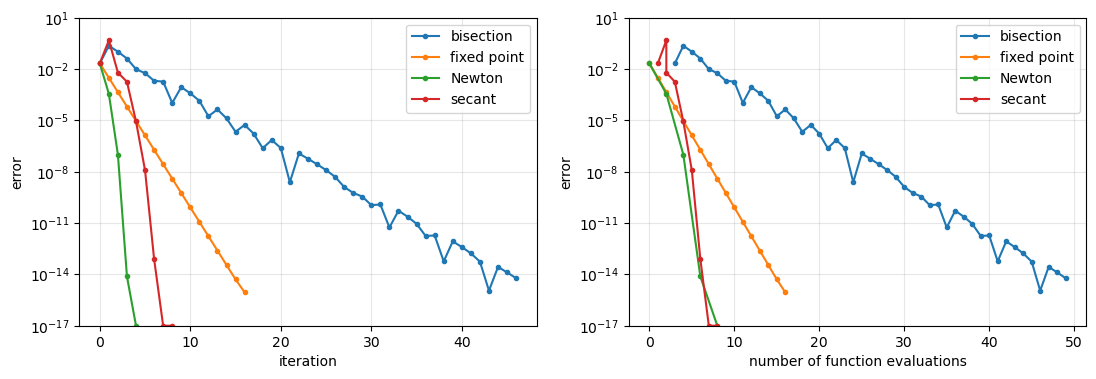

     method  iterations  f-evaluations theoretical order
  bisection          47             49         1 (bound)
fixed point          16             16                 1
     Newton           4              8                 2
     secant           7              8             1.618


In [27]:
f = lambda x: x**3 - x - 2
df = lambda x: 3 * x**2 - 1
g = lambda x: (x + 2)**(1 / 3)
xs_ref = optimize.brentq(f, 1, 2, xtol=1e-15)

_, bis_mids, _ = bisection(f, 1.0, 2.0, tol=1e-14)
_, fp_xs = fixed_point(g, 1.5, tol=1e-14)
_, nw_xs = newton(f, df, 1.5, tol=1e-14)
_, sc_xs = secant(f, 1.5, 2.0, tol=1e-14)

runs = {
    # name: (iterates, evaluations used to produce iterate k, theoretical order)
    "bisection": (bis_mids, 2 + np.arange(1, len(bis_mids) + 1), "1 (bound)"),
    "fixed point": (fp_xs, np.arange(len(fp_xs)), "1"),
    "Newton": (nw_xs, 2 * np.arange(len(nw_xs)), "2"),
    "secant": (sc_xs, np.r_[1, np.maximum(np.arange(1, len(sc_xs)), 2)], "1.618"),
}

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
rows = []
for name, (xs, evals, p_theory) in runs.items():
    e = errors(xs, xs_ref) + 1e-17
    ax[0].semilogy(e, "o-", ms=3, label=name)
    ax[1].semilogy(evals, e, "o-", ms=3, label=name)
    n_new = {"bisection": 0, "secant": 2}.get(name, 1)   # starting values are not iterations
    rows.append({"method": name, "iterations": len(xs) - n_new, "f-evaluations": evals[-1],
                 "theoretical order": p_theory})
for a, lab in zip(ax, ["iteration", "number of function evaluations"]):
    a.set_xlabel(lab); a.set_ylabel("error"); a.grid(True, which="both", alpha=0.3); a.legend()
    a.set_ylim(1e-17, 10)
plt.show()
print(pd.DataFrame(rows).to_string(index=False, float_format="{:.2f}".format))

Newton and the secant method reach machine precision after only a few iterates, too few for reliable order estimates with `estimate_order` (the secant estimates fluctuate a lot here). Section 7 shows a cleaner estimate for the secant method. Instead, compare the *shapes* of the curves: straight lines for bisection and fixed-point iteration, and curves that bend downwards for Newton and secant.

**Tasks**
- Why is the fixed-point iteration here much faster than in Example 3.2?
- Change the function and starting values and see how the picture changes. Can you find a case where bisection is the only method that works?

## 10 Combining robustness and speed: safeguarded Newton

Bisection always converges but is slow. Newton is fast but only near the root. A **safeguarded Newton method** combines them:

1. Keep a bracket $[a,b]$ with a sign change, and update it after each new function value.
2. Try a Newton step. If it lands **inside** the bracket, accept it; otherwise take a bisection step instead.

The bracket guarantees convergence; once we are close to the root, Newton steps are accepted and convergence becomes quadratic. The same idea, with secant and inverse quadratic interpolation instead of Newton, is behind **Brent's method** (`scipy.optimize.brentq`), the standard choice for scalar equations.

In [28]:
def safeguarded_newton(f, df, a, b, x0=None, tol=1e-12, max_iter=100):
    # Returns the root and a list of (x, step type) pairs.
    fa, fb = f(a), f(b)
    if np.sign(fa) == np.sign(fb):
        raise ValueError("f(a) and f(b) must have opposite signs")
    x = (a + b) / 2 if x0 is None else x0
    log = [(x, "start")]
    for _ in range(max_iter):
        fx = f(x)
        if fx == 0:
            return x, log
        # shrink the bracket using the new function value
        if np.sign(fx) == np.sign(fa):
            a, fa = x, fx
        else:
            b = x
        dfx = df(x)
        x_new = x - fx / dfx if dfx != 0 else np.inf
        if a < x_new < b:
            step = "Newton"
        else:
            x_new, step = (a + b) / 2, "bisection"
        log.append((x_new, step))
        if abs(x_new - x) < tol:
            return x_new, log
        x = x_new
    print("safeguarded_newton: max_iter reached")
    return x, log

root, log = safeguarded_newton(f_atan, df_atan, -5.0, 10.0, x0=4.2)
print(f"root {root:.12f}, exact 1 + tan(1/2) = {x_star_atan:.12f}\n")
print(pd.DataFrame(log, columns=["x", "step"]).to_string(float_format="{:.10f}".format))

root 1.546302489844, exact 1 + tan(1/2) = 1.546302489844

               x       step
0   4.2000000000      start
1  -4.4313247926     Newton
2  -0.1156623963  bisection
3   2.8922691125     Newton
4   0.2142370199     Newton
5   2.1001517147     Newton
6   1.3640002416     Newton
7   1.5349025812     Newton
8   1.5462484006     Newton
9   1.5463024886     Newton
10  1.5463024898     Newton


Plain Newton from $x_0 = 4.2$ diverged (Example 4.2). With the safeguard, the steps that would leave the bracket become bisection steps, and the last steps are Newton steps with quadratic convergence.

**Task.** Compare the number of function evaluations with `optimize.brentq(f_atan, -5, 10, full_output=True)`.

## 11 In practice: `scipy.optimize`

Now that you know how the methods work (and fail), use the library versions in practice.

| task | function | method |
|---|---|---|
| scalar equation, bracket known | `optimize.brentq(f, a, b)` | Brent: bisection + secant + inverse quadratic interpolation. Robust and fast; **the default choice** |
| scalar equation, starting guess | `optimize.newton(f, x0, fprime=df)` | Newton; without `fprime` it uses the **secant** method |
| system $\mathbf F(\mathbf x) = \mathbf 0$ | `optimize.root(F, x0, jac=J)` | Newton-type methods with safeguards |
| minimise $f(\mathbf x)$ | `optimize.minimize(f, x0, ...)` | BFGS, Newton-CG, trust-region, … |

Note that `minimize` needs more iterations on the Rosenbrock function than our plain Newton (Section 6). Its trust-region safeguard only accepts steps that decrease $f$. That costs some steps here, but it prevents convergence to maxima and saddle points and divergence from poor starting points.

In [29]:
r, info = optimize.brentq(f1, 1, 2, full_output=True)
print(f"brentq  x - cos x - 1 : {r:.12f}  ({info.function_calls} f-evaluations)")

r, info = optimize.newton(f1, 1.5, fprime=lambda x: 1 + np.sin(x), full_output=True)
print(f"newton  x - cos x - 1 : {r:.12f}  ({info.iterations} iterations)")

r, info = optimize.newton(f1, 1.5, full_output=True)          # no derivative -> secant
print(f"secant  x - cos x - 1 : {r:.12f}  ({info.iterations} iterations)")

sol = optimize.root(F_ell, [1, 1], jac=J_ell)
print(f"root    ellipse/curve : {sol.x}  ({sol.nfev} F-evaluations)")

res = optimize.minimize(optimize.rosen, [-1.2, 1.0], jac=optimize.rosen_der,
                        hess=optimize.rosen_hess, method="trust-exact")
print(f"minimize Rosenbrock   : {res.x}  ({res.nit} iterations)")

brentq  x - cos x - 1 : 1.283428741746  (7 f-evaluations)
newton  x - cos x - 1 : 1.283428741746  (4 iterations)
secant  x - cos x - 1 : 1.283428741746  (4 iterations)
root    ellipse/curve : [0.821682 1.139894]  (10 F-evaluations)
minimize Rosenbrock   : [1. 1.]  (25 iterations)


## 12 Summary

| method | requires | convergence | order | evaluations per step | strengths | weaknesses |
|---|---|---|---|---|---|---|
| bisection | continuous $f$, bracket $f(a)f(b)<0$ | guaranteed | 1 (bound halves) | 1 | robust, predictable number of steps | slow; 1D only; misses roots without a sign change |
| fixed point | rewriting $x = g(x)$ with $\lvert g'(x^*)\rvert < 1$ | local (global for a contraction) | 1, $C = \lvert g'(x^*)\rvert$ | 1 ($g$) | simple; also a model of dynamics | depends on the rewriting; slow if $C \approx 1$ |
| Newton | $f'$, good $x_0$ | local | 2 (1 at multiple roots) | 2 ($f$ and $f'$) | very fast; extends to systems and optimisation | needs $f'$; can diverge; problems when $f' \approx 0$ |
| secant | two starting values | local | 1.618 | 1 | no derivative; most efficient per evaluation | can diverge; breaks down if $f(x_n)\approx f(x_{n-1})$ |
| safeguarded / Brent | bracket | guaranteed | superlinear | about 1 | robust **and** fast | 1D only |

**Take-home messages**

- Always **plot** $f$ (or the zero contours of $\mathbf F$) first to find how many roots there are and where to start.
- Theory predicts behaviour: $|g'(x^*)|$ decides fixed-point convergence; $f'(x^*) \ne 0$ gives Newton quadratic convergence.
- Check the order of convergence *numerically* with a semilog error plot or `estimate_order`.
- Robust + fast = bracketing with fast local steps (`brentq`).

## Exercises

**1. Kepler's equation.** The position of a planet in its elliptical orbit is found from Kepler's equation
$$
M = E - \varepsilon \sin E,
$$
where $M$ is the mean anomaly, $\varepsilon$ the eccentricity, and $E$ the unknown eccentric anomaly. Take $M = 1$ and $\varepsilon = 0.5$.
- (a) Show that $g(E) = M + \varepsilon\sin E$ is a contraction on $\mathbb R$ with $k = \varepsilon$. Use Theorem 3.1 to predict how many iterations are needed for an error below $10^{-10}$, and check.
- (b) Solve with Newton's method and estimate the order of convergence.
- (c) Repeat with $\varepsilon = 0.99$. What happens to each method?

**2. Division without dividing.** Early computers computed $1/a$ with Newton's method applied to $f(x) = 1/x - a$.
- (a) Show that the Newton iteration is $x_{n+1} = x_n(2 - a x_n)$, which uses only multiplication and subtraction.
- (b) Show that $e_{n+1} = -a\,e_n^2$ exactly, where $e_n = x_n - 1/a$. For which $x_0$ does it converge?

**3. Order of convergence from data.** Solve $\cos x = x$ with bisection, fixed-point iteration $x = \cos x$, Newton and secant. Make one semilog error plot and estimate the order of each method with `estimate_order`. Compare with the theory, including the rate $|g'(x^*)|$ for the fixed-point iteration.

**4. A system.** Find all intersections of the circle $x^2 + y^2 = 4$ and the curve $y = e^x - 1$. Plot first, then use your own `newton_system` and `optimize.root`, and compare the number of iterations.